# **Data cleaning**

In [ ]:
#%% Importation des données et modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import fbeta_score, accuracy_score, recall_score
from sklearn.model_selection import cross_val_predict,StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier



In [ ]:
#Lecture du fichier csv
df = pd.read_csv("/content/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [ ]:
# 1. Chargement
df = pd.read_csv("credit_risk_dataset.csv")

# 2. Création des indicateurs de données manquantes
df['is_missing_rate'] = df['loan_int_rate'].isna()
df['is_missing_emplength'] = df['person_emp_length'].isna()

# 3. Nettoyage des Outliers (On garde les données réalistes)
df = df[
    (df['person_age'] < 100) &
    ((df['person_emp_length'] < 60) | (df['person_emp_length'].isna()))
].copy()

# 4. Imputation par la médiane (Méthode sans Warning)
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())


Imputation par la médiane et création d'une variable "donnée manquante"

**Encoding des variables catégorielles**

In [ ]:
# 5. Encodage des variables binaires et ordinales
# cb_person_default_on_file : Y/N -> 1/0
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].replace({'Y': 1, 'N': 0})

# loan_grade : Ordinal mapping (A=1, B=2, ...)
mapping_grade = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['loan_grade'] = df['loan_grade'].map(mapping_grade)

# 6. Encodage des variables nominales (One-Hot)
# On définit explicitement les colonnes pour être sûr
cols_to_encode = ['person_home_ownership', 'loan_intent']
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# 7. Séparation X et y
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 8. Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Prétraitement réussi !")
print(f"Forme de X_train : {X_train.shape}")

/tmp/ipython-input-1008382565.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['cb_person_default_on_file'] = df['cb_person_default_on_file'].replace({'Y': 1, 'N': 0})


Prétraitement réussi !
Forme de X_train : (26059, 19)


# **1.Regression logistique**

ROC AUC Score RL : 0.8568

Classification Report RL:
               precision    recall  f1-score   support

           0       0.92      0.80      0.86      5094
           1       0.52      0.76      0.61      1421

    accuracy                           0.79      6515
   macro avg       0.72      0.78      0.74      6515
weighted avg       0.83      0.79      0.81      6515


Matrice de confusion:
Vrais Négatifs (Sains)   : 4092 | Faux Positifs (Erreurs) : 1002
Faux Négatifs (DANGEREUX): 348 | Vrais Positifs (Défauts): 1073


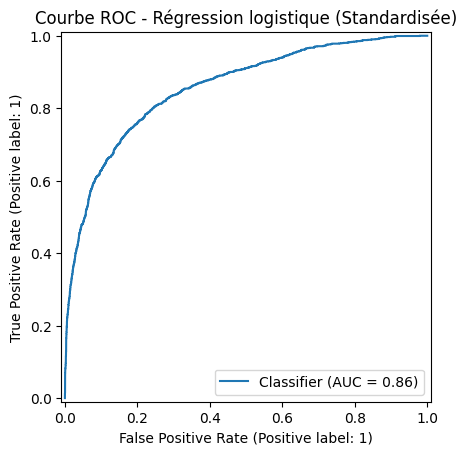

In [ ]:
#1ere méthode : Regression logistique

def train_logistic_regression(X_train, y_train, X_test, y_test):
    """
    Entraîne et évalue un modèle de Régression Logistique pour le risque de crédit.

    Cette fonction utilise un Pipeline pour standardiser les données avant l'entraînement,
    ce qui est crucial pour la convergence de la Régression Logistique. Elle gère
    le déséquilibre des classes via le paramètre 'balanced'.

    Args:
        X_train (pd.DataFrame): Features d'entraînement.
        y_train (pd.Series): Cible d'entraînement (loan_status).
        X_test (pd.DataFrame): Features de test.
        y_test (pd.Series): Cible de test.

    Returns:
        Pipeline: Le modèle complet (scaler + logreg) entraîné.
    """

    # Amélioration 1 : Utilisation d'un Pipeline pour inclure le StandardScaler
    # Cela garantit que le scaling est fait correctement sans fuite de données (data leakage)
    model_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(
            penalty='l2',
            solver='liblinear',
            class_weight='balanced',
            random_state=42
        ))
    ])

    # Entraînement
    model_pipeline.fit(X_train, y_train)

    # Prédictions
    y_pred = model_pipeline.predict(X_test)
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]

    # Évaluation
    print(f"ROC AUC Score RL : {roc_auc_score(y_test, y_proba):.4f}")
    print("\nClassification Report RL:\n", classification_report(y_test, y_pred))

    # Amélioration 2 : Matrice de confusion avec labels pour plus de clarté
    cm = confusion_matrix(y_test, y_pred)
    print("\nMatrice de confusion:")
    print(f"Vrais Négatifs (Sains)   : {cm[0][0]} | Faux Positifs (Erreurs) : {cm[0][1]}")
    print(f"Faux Négatifs (DANGEREUX): {cm[1][0]} | Vrais Positifs (Défauts): {cm[1][1]}")

    # Visualisation
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title("Courbe ROC - Régression logistique (Standardisée)")
    plt.show()

    return model_pipeline

# Appel de la fonction
logreg_model = train_logistic_regression(X_train, y_train, X_test, y_test)

In [ ]:
from sklearn.utils import class_weight


# Configuration de la validation croisée stratifiée
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. RÉG LOG L1

pipeline_l1 = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ))
])

param_grid_l1 = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_l1 = GridSearchCV(
    pipeline_l1,
    param_grid_l1,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_l1.fit(X_train, y_train)

print(f"\nMeilleurs paramètres L1: {grid_l1.best_params_}")
print(f"Meilleur ROC-AUC (CV) L1: {grid_l1.best_score_:.4f}")

y_pred_proba_l1 = grid_l1.predict_proba(X_test)[:, 1]
y_pred_l1 = grid_l1.predict(X_test)
roc_auc_l1_test = roc_auc_score(y_test, y_pred_proba_l1)
print(f"ROC-AUC sur test L1: {roc_auc_l1_test:.4f}")

# Nombre de coefficients non nuls (sélection de variables)
coef_l1 = grid_l1.best_estimator_.named_steps['classifier'].coef_[0]
n_features_l1 = np.sum(coef_l1 != 0)
print(f"Nombre de variables sélectionnées (coef ≠ 0): {n_features_l1}/{len(coef_l1)}")


# 2. RÉG LOG L2


print("RÉGRESSION LOGISTIQUE - PÉNALISATION L2 (RIDGE)")

pipeline_l2 = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='l2',
        solver='liblinear',
        random_state=42,
        max_iter=1000
    ))
])

param_grid_l2 = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_l2 = GridSearchCV(
    pipeline_l2,
    param_grid_l2,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_l2.fit(X_train, y_train)

print(f"\nMeilleurs paramètres L2: {grid_l2.best_params_}")
print(f"Meilleur ROC-AUC (CV) L2: {grid_l2.best_score_:.4f}")

y_pred_proba_l2 = grid_l2.predict_proba(X_test)[:, 1]
roc_auc_l2_test = roc_auc_score(y_test, y_pred_proba_l2)
print(f"ROC-AUC sur test L2: {roc_auc_l2_test:.4f}")

coef_l2 = grid_l2.best_estimator_.named_steps['classifier'].coef_[0]


# 3. RÉG LOG ELASTIC NET


pipeline_en = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        random_state=42,
        max_iter=1000
    ))
])

param_grid_en = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10],
    'classifier__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_en = GridSearchCV(
    pipeline_en,
    param_grid_en,
    cv=cv_strategy,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_en.fit(X_train, y_train)

print(f"\nMeilleurs paramètres Elastic Net: {grid_en.best_params_}")
print(f"Meilleur ROC-AUC (CV) Elastic Net: {grid_en.best_score_:.4f}")

y_pred_proba_en = grid_en.predict_proba(X_test)[:, 1]
roc_auc_en_test = roc_auc_score(y_test, y_pred_proba_en)
print(f"ROC-AUC sur test Elastic Net: {roc_auc_en_test:.4f}")

coef_en = grid_en.best_estimator_.named_steps['classifier'].coef_[0]
n_features_en = np.sum(coef_en != 0)
print(f"Nombre de variables sélectionnées: {n_features_en}/{len(coef_en)}")


# 4. COMPARAISON DES RÉSULTATS

results = pd.DataFrame({
    'Pénalisation': ['L1 (Lasso)', 'L2 (Ridge)', 'Elastic Net'],
    'ROC-AUC (CV)': [
        grid_l1.best_score_,
        grid_l2.best_score_,
        grid_en.best_score_
    ],
    'ROC-AUC (Test)': [
        roc_auc_l1_test,
        roc_auc_l2_test,
        roc_auc_en_test
    ],
    'Variables sélectionnées': [
        n_features_l1,
        len(coef_l2),
        n_features_en
    ],
    'Meilleur C': [
        grid_l1.best_params_['classifier__C'],
        grid_l2.best_params_['classifier__C'],
        grid_en.best_params_['classifier__C']
    ]
})





Fitting 5 folds for each of 6 candidates, totalling 30 fits

Meilleurs paramètres L1: {'classifier__C': 0.1}
Meilleur ROC-AUC (CV) L1: 0.8668
ROC-AUC sur test L1: 0.8570
Nombre de variables sélectionnées (coef ≠ 0): 19/19
RÉGRESSION LOGISTIQUE - PÉNALISATION L2 (RIDGE)
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Meilleurs paramètres L2: {'classifier__C': 0.1}
Meilleur ROC-AUC (CV) L2: 0.8662
ROC-AUC sur test L2: 0.8563
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Meilleurs paramètres Elastic Net: {'classifier__C': 0.1, 'classifier__l1_ratio': 0.9}
Meilleur ROC-AUC (CV) Elastic Net: 0.8663
ROC-AUC sur test Elastic Net: 0.8564
Nombre de variables sélectionnées: 19/19


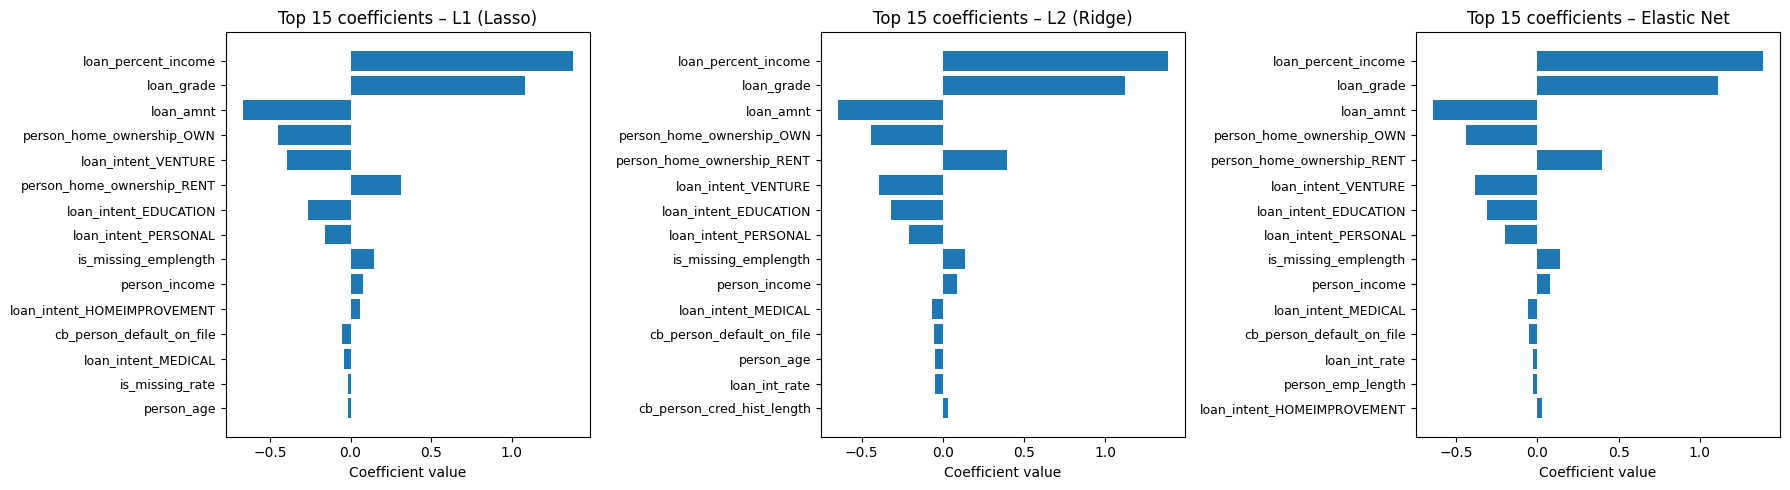

In [ ]:
#VISUALISATION DES RESULTATS


feature_names = X_train.columns.to_numpy()


models = {
    'L1 (Lasso)': coef_l1,
    'L2 (Ridge)': coef_l2,
    'Elastic Net': coef_en
}

fig, axes = plt.subplots(1, 3,figsize=(18, 5),sharey=False)

for ax, (model_name, coef) in zip(axes, models.items()):


    idx = np.argsort(np.abs(coef))[-15:]

    coef_selected = coef[idx]
    features_selected = feature_names[idx]



    ax.barh(features_selected, coef_selected)


    ax.set_title(f'Top 15 coefficients – {model_name}')
    ax.set_xlabel('Coefficient value')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(
    'comparison_regularization_coefficients.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# **Random forest**

In [ ]:
# RF

param_grid = {
    'n_estimators': [100, 200,500],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 10],
    'max_features': ['sqrt', 'log2']
}


grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best model
rf_opti = grid_search.best_estimator_
print("Meilleurs hyperparamètres : ", grid_search.best_params_)

y_pred_rf_opti = rf_opti.predict(X_test)
y_proba_rf_opti = rf_opti.predict_proba(X_test)[:, 1]


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Meilleurs hyperparamètres :  {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 500}


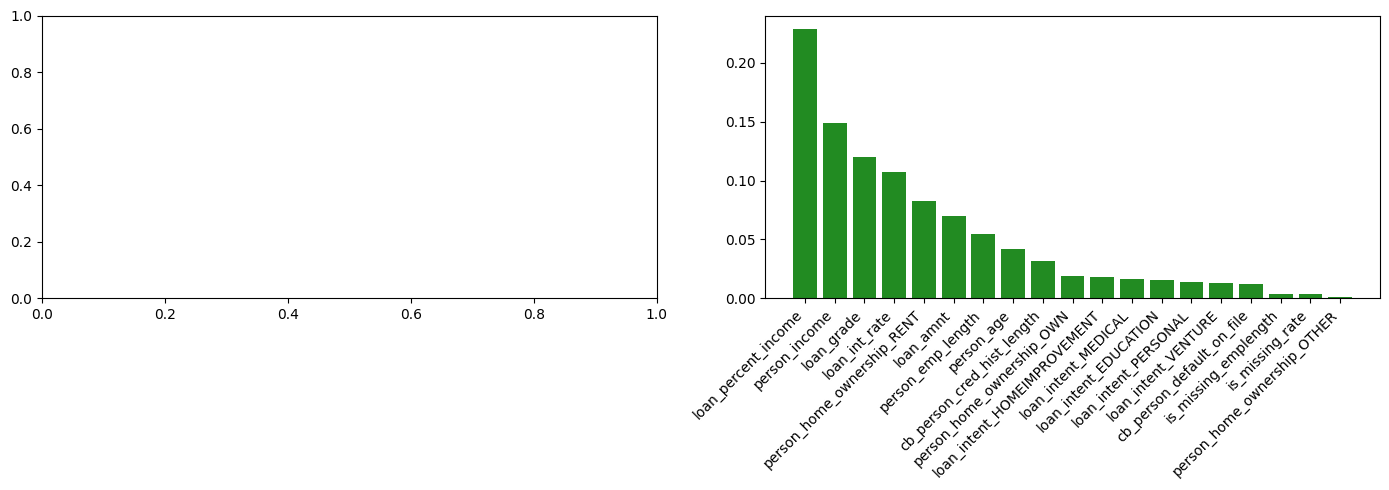

In [ ]:
# Feature Importance

importances = rf_opti.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[1].bar(range(len(indices)), importances[indices], color='forestgreen')
ax[1].set_xticks(range(len(indices)))
ax[1].set_xticklabels([features[i] for i in indices], rotation=45, ha='right')


plt.tight_layout()
plt.show()


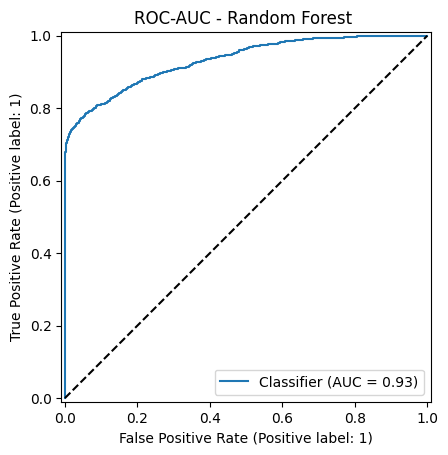

Classification Report (Random Forest ):
               precision    recall  f1-score   support

           0       0.92      1.00      0.96      5094
           1       0.98      0.71      0.82      1421

    accuracy                           0.93      6515
   macro avg       0.95      0.85      0.89      6515
weighted avg       0.94      0.93      0.93      6515

AUC-ROC Score: 0.9323753545933219
Confusion Matrix:
 [[5071   23]
 [ 418 1003]]


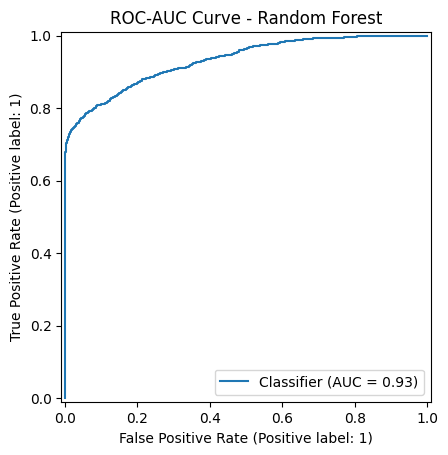

In [ ]:
# 3. Courbe ROC
RocCurveDisplay.from_predictions(y_test, y_proba_rf_opti)
plt.title("ROC-AUC - Random Forest ")
plt.plot([0, 1], [0, 1], 'k--')
plt.show()
# Évaluation
print("Classification Report (Random Forest ):\n", classification_report(y_test, y_pred_rf_opti))
print("AUC-ROC Score:", roc_auc_score(y_test, y_proba_rf_opti))

mat_conf_rf_opti = confusion_matrix(y_test, y_pred_rf_opti)
print("Confusion Matrix:\n", mat_conf_rf_opti)

RocCurveDisplay.from_predictions(y_test, y_proba_rf_opti)
plt.title("ROC-AUC Curve - Random Forest")
plt.show()

# **xgboost**

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:26:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:27:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500, 'subsample': 1}
Best ROC AUC Score: 0.9460886995074017

Classification Report XGBoost:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      5094
           1       0.96      0.73      0.83      1421

    accuracy                           0.93      6515
   macro avg       0.95      0.86      0.89      6515
weighted avg       0.94      0.93      0.93      6515



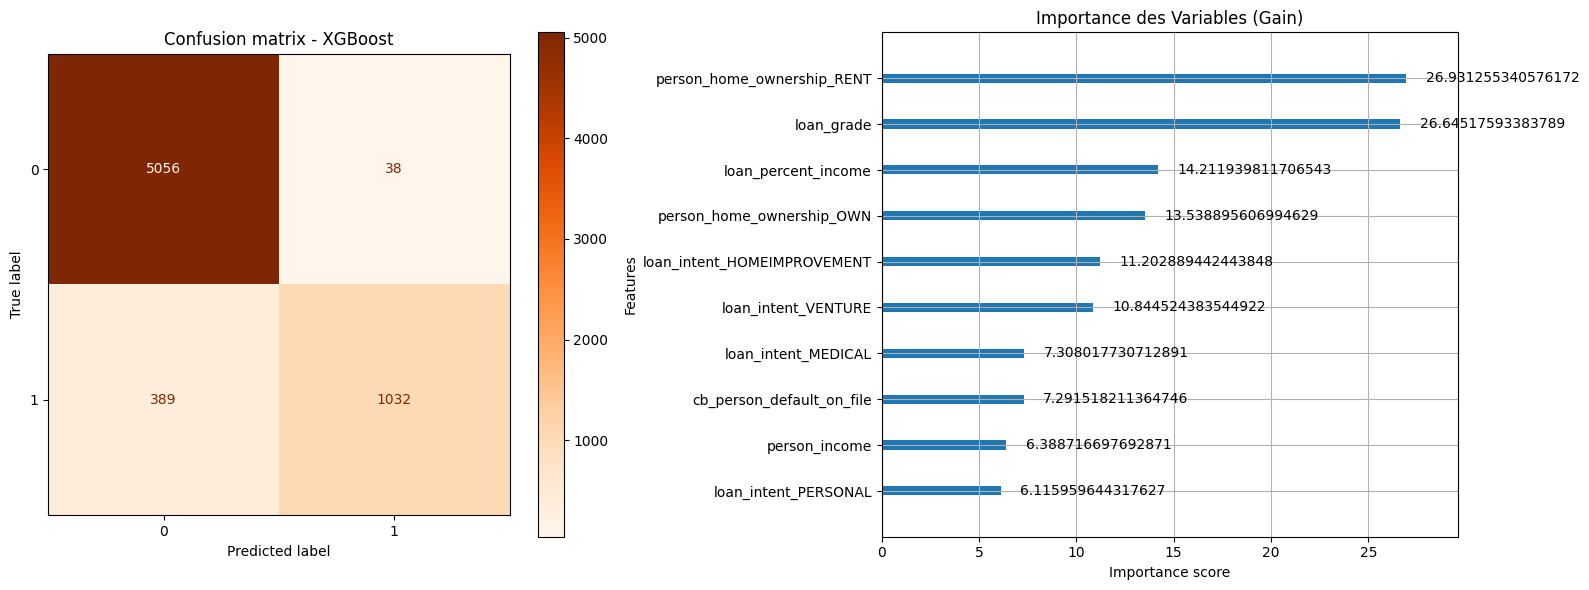

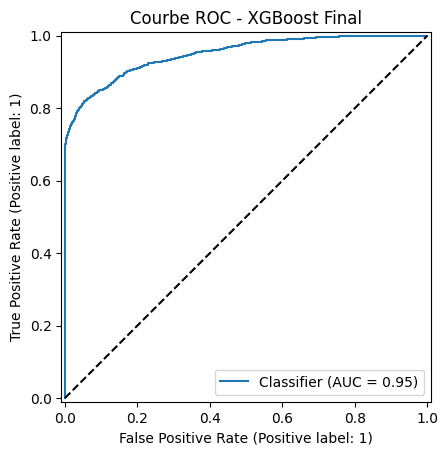

In [ ]:
import xgboost as xgb

# 1. Création du modèle de base
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)

# Entraînement initial
xgb_clf.fit(X_train, y_train)

# 2. Recherche par grille (GridSearchCV)
param_grid = {
    'n_estimators': [100, 500],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic',
        use_label_encoder=False,
        eval_metric='auc',
        n_jobs=-1,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3, # Réduit à 3 pour la démo
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 3. Évaluation du meilleur modèle
print("Best Parameters:", grid_search.best_params_)
print("Best ROC AUC Score:", grid_search.best_score_)

best_xgb = grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("\nClassification Report XGBoost:\n", classification_report(y_test, y_pred_xgb))



# Confusion matrix
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap='Oranges', ax=ax[0])
ax[0].set_title("Confusion matrix - XGBoost")

# Feature importance
xgb.plot_importance(best_xgb, ax=ax[1], max_num_features=10, importance_type='gain', title="Importance des Variables (Gain)")
plt.tight_layout()
plt.show()

# ROC
RocCurveDisplay.from_predictions(y_test, y_proba_xgb)
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Courbe ROC - XGBoost Final")
plt.show()

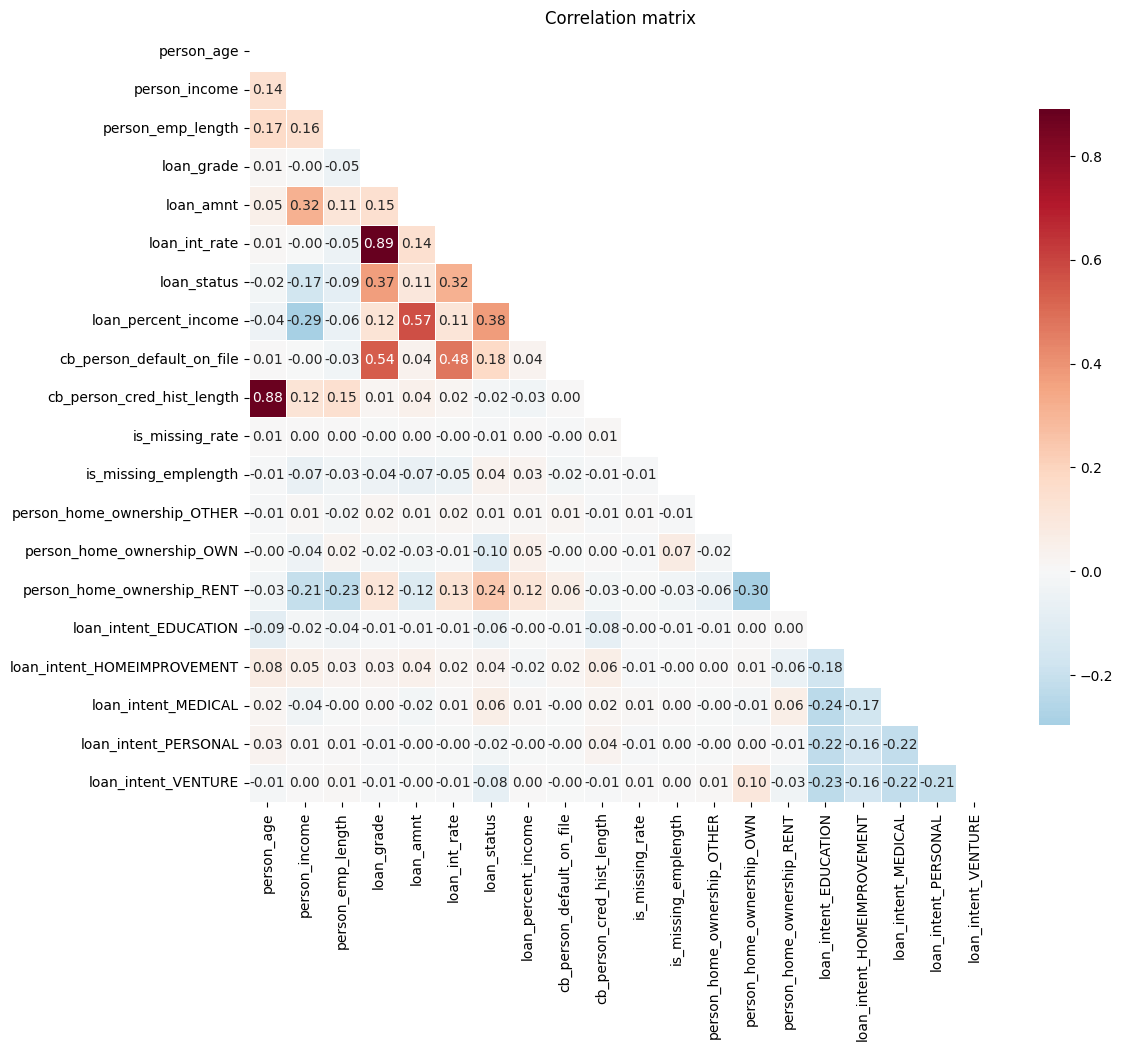

In [ ]:
corr_matrix = df.corr()

# 2. Configuration de l'affichage
plt.figure(figsize=(12, 10))

# Création d'un masque pour ne voir que la partie inférieure (évite la redondance)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Génération de la Heatmap
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Correlation matrix')
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.metrics import fbeta_score
# Logistic Regression

f2_log = fbeta_score(y_test, y_pred_l1, beta=2)


# Random Forest

f2_rf = fbeta_score(y_test, y_pred_rf_opti, beta=2)


# XGBoost

f2_xgb = fbeta_score(y_test, y_pred_xgb, beta=2)


# Affichage des F2 scores
print("F2 Scores:")
print(f"Logistic Regression: {f2_log:.3f}")
print(f"Random Forest: {f2_rf:.3f}")
print(f"XGBoost: {f2_xgb:.3f}")




F2 Scores:
Logistic Regression: 0.692
Random Forest: 0.747
XGBoost: 0.764


# **Reseau de neuronnes**

In [ ]:
from sklearn.neural_network import MLPClassifier
# ==============================================================================
# CHALLENGER 3 : RÉSEAU DE NEURONES (MLP) -
# ==============================================================================

# Le scaling est obligatoire pour que le MLP converge bien
pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        max_iter=1000,           # Suffisamment d'itérations
        early_stopping=True,     # Arrêt si le modèle n'apprend plus (évite l'overfitting)
        validation_fraction=0.1, # 10% des données pour valider l'arrêt
        random_state=42
    ))
])

# 2. GRILLE DE RECHERCHE (GridSearch)
# On cherche les hyperparamètres qui maximisent le ROC-AUC (discrimination pure)
param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(64, 32), (128, 64, 32)], # Structures testées
    'mlp__activation': ['tanh', 'relu'],
    'mlp__alpha': [0.01, 0.05] # Régularisation
}

print("--- Entraînement du MLP en cours (patience...) ---")
grid_mlp = GridSearchCV(pipeline_mlp, param_grid_mlp, cv=5, scoring='roc_auc', n_jobs=-1)
grid_mlp.fit(X_train, y_train)

best_mlp = grid_mlp.best_estimator_
print(f"Meilleurs paramètres : {grid_mlp.best_params_}")


--- Entraînement du MLP en cours (patience...) ---
Meilleurs paramètres : {'mlp__activation': 'tanh', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (128, 64, 32)}


In [ ]:
# 3. PRÉDICTIONS (PROBABILITÉS)
# On récupère la probabilité d'être en défaut (classe 1)
y_proba_mlp = best_mlp.predict_proba(X_test)[:, 1]

# 4. CALCUL DU ROC-AUC
auc_score = roc_auc_score(y_test, y_proba_mlp)
print(f"\n>>> ROC-AUC Score : {auc_score:.3f}")

# 5. OPTIMISATION DU SEUIL POUR LE SCORE F2 (Approche Business)
# On teste 100 seuils pour trouver celui qui minimise les pertes financières (F2)
thresholds = np.linspace(0, 1, 100)
f2_scores = [fbeta_score(y_test, (y_proba_mlp >= t).astype(int), beta=2) for t in thresholds]

best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

print(f">>> Meilleur Seuil (Threshold) : {best_threshold:.2f}")
print(f">>> Score F2 Optimisé : {best_f2:.3f}")


>>> ROC-AUC Score : 0.906
>>> Meilleur Seuil (Threshold) : 0.18
>>> Score F2 Optimisé : 0.743



--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      5094
           1       0.69      0.76      0.72      1421

    accuracy                           0.87      6515
   macro avg       0.81      0.83      0.82      6515
weighted avg       0.88      0.87      0.88      6515

--- Matrice de Confusion (Seuil Optimisé) ---


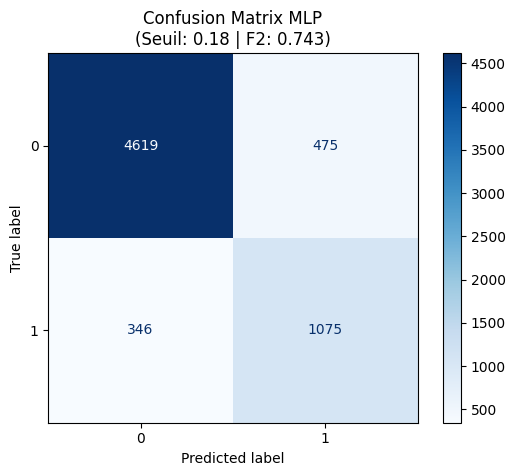

In [ ]:
# 6. VISUALISATION FINALE
# On applique le meilleur seuil pour voir la matrice de confusion réelle
y_final_pred = (y_proba_mlp >= best_threshold).astype(int)

print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_final_pred))

print("--- Matrice de Confusion (Seuil Optimisé) ---")
ConfusionMatrixDisplay.from_predictions(y_test, y_final_pred, cmap='Blues')
plt.title(f"Confusion Matrix MLP\n(Seuil: {best_threshold:.2f} | F2: {best_f2:.3f})")
plt.show()

Meilleurs paramètres trouvés : {'mlp__activation': 'tanh', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (128, 64, 32)}
Score F2 du MLP (seuil 0.5) : 0.712


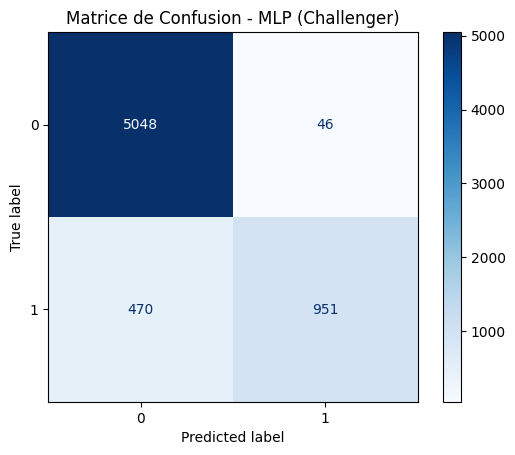

In [ ]:
# 1. Afficher les meilleurs paramètres trouvés
print(f"Meilleurs paramètres trouvés : {grid_mlp.best_params_}")

# 2. Calculer le score F2 (le plus important selon votre rapport)
from sklearn.metrics import fbeta_score

# On utilise d'abord le seuil par défaut (0.5) pour tester
y_pred_mlp_default = (y_proba_mlp >= 0.5).astype(int)
f2_mlp_default = fbeta_score(y_test, y_pred_mlp_default, beta=2)

print(f"Score F2 du MLP (seuil 0.5) : {f2_mlp_default:.3f}")

# 3. Afficher la matrice de confusion pour voir les défauts détectés
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp_default, cmap='Blues')
plt.title("Matrice de Confusion - MLP (Challenger)")
plt.show()

In [ ]:
# Fonction pour trouver le seuil qui maximise le score F2
def find_best_f2_threshold(y_true, y_probs):
    thresholds = np.linspace(0, 1, 100)
    scores = [fbeta_score(y_true, (y_probs >= t).astype(int), beta=2) for t in thresholds]
    best_threshold = thresholds[np.argmax(scores)]
    return best_threshold, max(scores)

best_thresh_mlp, best_f2_mlp = find_best_f2_threshold(y_test, y_proba_mlp)

# Prédiction finale avec le seuil optimisé
y_pred_mlp_custom = (y_proba_mlp >= best_thresh_mlp).astype(int)

print(f"Meilleur Seuil MLP : {best_thresh_mlp:.2f}")
print(f"Score F2 MLP : {best_f2_mlp:.3f}")

Meilleur Seuil MLP : 0.18
Score F2 MLP : 0.743


/tmp/ipython-input-2651845970.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=f2_values, palette='viridis')


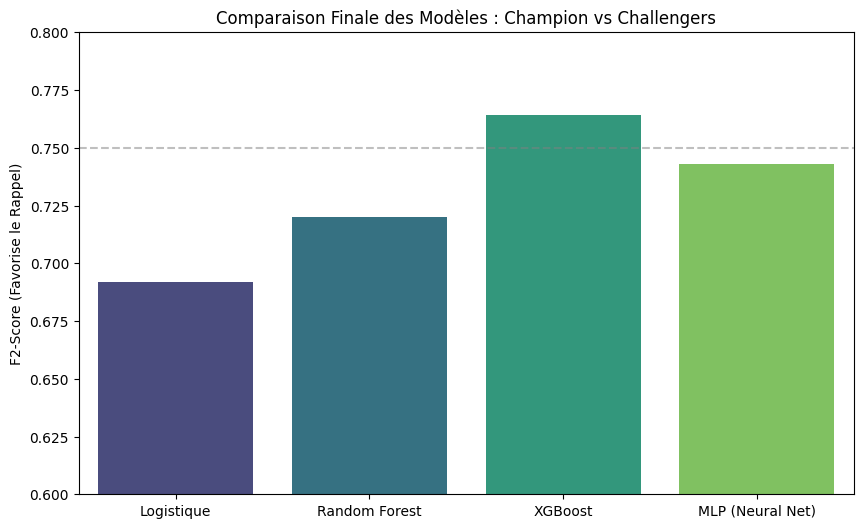

In [ ]:
model_names = ['Logistique', 'Random Forest', 'XGBoost', 'MLP (Neural Net)']
f2_values = [0.692, 0.720, 0.764, 0.743] # Remplacez par vos variables exactes

plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=f2_values, palette='viridis')
plt.ylim(0.6, 0.8) # Zoomer sur la zone intéressante
plt.axhline(0.75, color='grey', linestyle='--', alpha=0.5)
plt.ylabel('F2-Score (Favorise le Rappel)')
plt.title('Comparaison Finale des Modèles : Champion vs Challengers')
plt.show()